# HMM Market Regime Detection — IHSG (^JKSE)

> **Setup:** This notebook requires Python 3.10+ with dependencies listed in `requirements.txt`.
> To install: `pip install -r requirements.txt`

## Overview

This notebook adapts the SPY HMM regime detection model to the **Indonesian Stock Exchange Composite Index (IHSG / ^JKSE)**. The goal is to classify each trading day into one of three regimes: **Bull, Neutral, and Bear**, purely from price-derived features, without any manual labeling.

A **Hidden Markov Model** assumes the market is always in one of a few unobservable "states" (here, our three regimes). We never see the state directly — we only see the day's returns, volatility, and so on, and the model *infers* the most likely hidden state behind each day's observations, plus how often the market transitions between states.

### Model Summary

| Component | Choice | Reason |
|---|---|---|
| Model | GaussianHMM | Returns within each state are approximately Gaussian — verified empirically |
| States | 3 | Justified by AIC/BIC analysis — cleaner separation than 4 states for IHSG |
| Features | Returns, Volatility, Momentum, Drawdown | Captures direction, risk, trend, and distance from recent peak |
| Scaler | RobustScaler | Resistant to outliers like crash days |
| Data | IHSG 1996-2026 | Covers 2008, COVID, and multiple bull markets |
| Split | 80/20 | Larger test set to evaluate generalization on newer market dynamics |

### Regime label definitions
Regime labels refer to **statistical regimes** — clusters of days with similar return and volatility behavior. IHSG has a significantly higher proportion of Bear days than SPY, reflecting the higher volatility nature of emerging markets.

In [24]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data & Feature Engineering

We download daily OHLCV data for IHSG (^JKSE) from Yahoo Finance using `yfinance`. Adjusted prices (`auto_adjust=True`) account for dividends and stock splits.

### Why 1996 as the start date?
Starting from 1996 provides sufficient historical diversity — the 1997 & 2008 financial crisis, 2020 COVID crash, and post-COVID recovery. Earlier Yahoo Finance data for IHSG has known quality issues.

### Features
- **Returns** — daily log return: captures price direction
- **Volatility** — 20-day rolling standard deviation: captures risk level
- **Momentum** — 10-day rolling mean of returns: captures short-term trend
- **Drawdown** — log ratio of current price to 252-day rolling maximum: captures distance from recent peak. Always zero or negative — large negative values indicate sustained bear conditions

### Note on commented features
Several features (long momentum, volume, overnight gap) are computed but commented out. These were tested during experimentation but either degraded model performance or were unreliable for IHSG data.

In [25]:
#Data (We use log returns)
data = yf.download('^JKSE', start='1995-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
open = data['Open'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

long_momentum =returns.rolling(30).mean()

overnight_gap = np.log(open / close.shift(1))

rolling_max = close.rolling(252).max()
drawdown = np.log(close / rolling_max)

#TESTER MAYBE REMOVE
volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    #'momentum': momentum,
    'long_momentum': long_momentum,
    #'volume': relative_volume,
    #'open_close': overnight_gap
    'drawdown': drawdown
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 7294 trading days
             returns  volatility  long_momentum  drawdown
Date                                                     
1996-01-09 -0.004305    0.010711       0.004863 -0.004642
1996-01-10 -0.004097    0.010594       0.003947 -0.008739
1996-01-11  0.009676    0.010671       0.004318  0.000000
1996-01-12  0.031733    0.011905       0.005092  0.000000
1996-01-15  0.023160    0.012282       0.005805  0.000000


## 2. Train/Test Split

We split the data chronologically — 80% training, 20% testing. We chose this simply out of convention.

In [26]:
split = int(len(features) * 0.8)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 5835 days
Test:  1459 days


## 3. Model Training

### Why RobustScaler?
The four features operate on different scales. RobustScaler normalizes using the median and interquartile range, making it resistant to extreme outliers common in emerging market data.

### Why 3 states?
Unlike the SPY model which uses 4 states, IHSG performs better with 3 states (Bear, Neutral, Bull). The 4-state model for IHSG collapsed Strong Bull and Weak Bull into nearly identical clusters, making the extra state meaningless. AIC/BIC analysis confirmed n=3 as the appropriate choice for this feature set and market.

Training uses the **Baum-Welch algorithm** (EM) until convergence.

In [27]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train)

print(f"Converged: {model.monitor_.converged}")

Converged: True


## 4. Regime Detection

The **Viterbi algorithm** labels each trading day with its most likely hidden state. States are labeled post-hoc by sorting mean returns — computed on the **training set only** to prevent look-ahead bias in the labeling step.

In [28]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[:split][states[:split] == s].mean() for s in range(3)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    sorted_states[2]: 'Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    sorted_states[2]: "#3c902b",   # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Neutral': '0.0001', 'Bull': '0.0016', 'Bear': '-0.0005'}


## 5. Regime Smoothing

Short-duration regime flips (less than 10 consecutive days) are absorbed into the surrounding regime. This reduces visual noise in the chart — brief 1-3 day regime switches are unlikely to represent meaningful regime changes and are more likely model uncertainty at transition boundaries.

Note: smoothing is applied only for visualization. The raw `states` array (unsmoothed) is used for all quantitative evaluation metrics.

In [29]:
def smooth_regimes(states, min_days=10):
    s = states.copy()
    i = 0
    while i < len(s):
        j = i
        while j < len(s) and s[j] == s[i]:
            j += 1
        if j - i < min_days and i > 0:        # run too short -> absorb into previous regime
            s[i:j] = s[i-1]
        i = j
    return s

smoothed_states = smooth_regimes(states, min_days=10)

## 6. Regime Visualization

The chart below shows the IHSG price history shaded by detected regime (smoothed). The dashed vertical line marks the train/test split.

Key periods to observe:
- **2008-2009** — global financial crisis impact on Indonesian market
- **2020** — COVID crash
- **2013-2015** — IHSG weakness (commodity downcycle, currency depreciation)
- **Post-2020** — strong recovery period

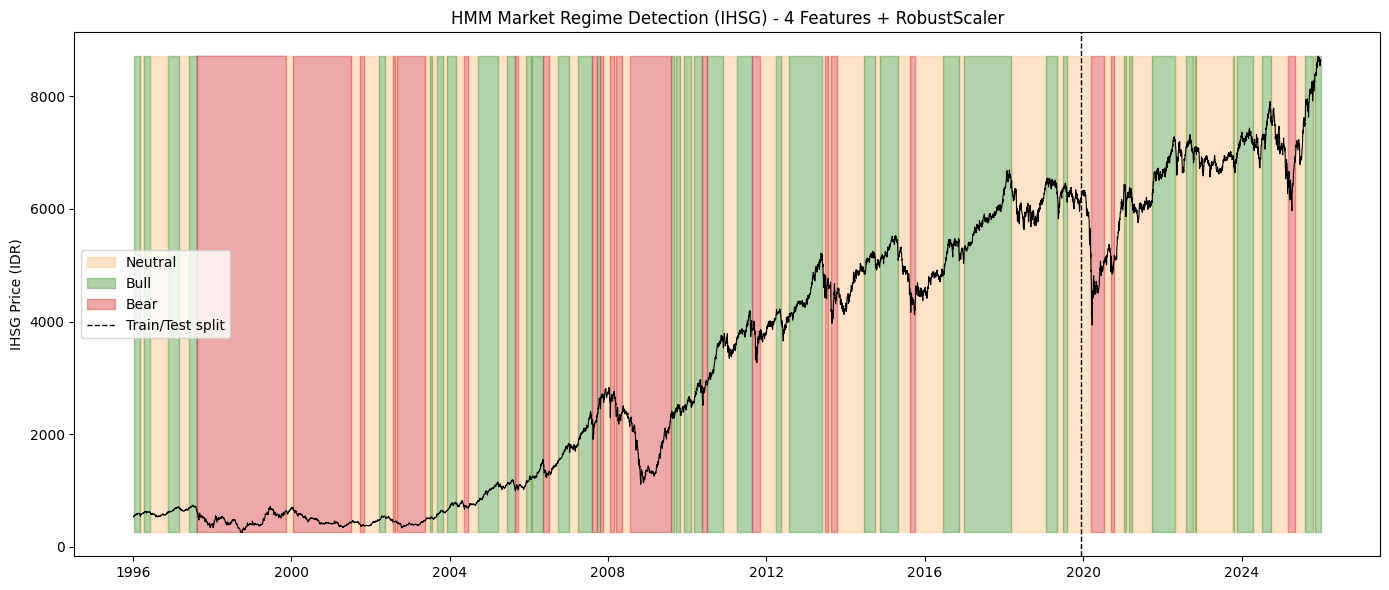

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(3):
    mask = (smoothed_states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (IHSG) - 4 Features + RobustScaler')
plt.ylabel('IHSG Price (IDR)')
plt.tight_layout()
plt.show()

## 7. Regime Statistics

Mean return, volatility, and day count per regime using the raw unsmoothed states.

In [31]:
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Neutral  | Mean: 0.0000 | Std: 0.0109 | Days: 2954
Bull     | Mean: 0.0014 | Std: 0.0081 | Days: 2487
Bear     | Mean: -0.0005 | Std: 0.0231 | Days: 1853


## 8. Train/Test Regime Distribution

Compares the proportion of days in each regime between the training and test sets. Large differences suggest the market dynamics in the test period differ significantly from training — a key concern for emerging markets where structural breaks are more common.

In [32]:
# Check if test set regimes look sane vs train set
test_states = model.predict(scaler.transform(test_features))

print("Train regime distribution:")
for state in range(3):
    pct = (states[:split] == state).sum() / split * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

print("\nTest regime distribution:")
for state in range(3):
    pct = (test_states == state).sum() / len(test_states) * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

Train regime distribution:
  Neutral     : 36.5%
  Bull        : 34.2%
  Bear        : 29.3%

Test regime distribution:
  Neutral     : 56.6%
  Bull        : 33.6%
  Bear        : 9.8%


## 9. Model Evaluation

### 9.1 AIC/BIC — Justifying Number of States

Using built-in `model.aic()` and `model.bic()` from `hmmlearn`. Lower is better. The elbow point in the BIC curve justifies our choice of n=3 states for IHSG.

In [33]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 52783.76 | BIC: 52997.50 | Converged: True
n=3 | AIC: 44360.73 | BIC: 44705.47 | Converged: True
n=4 | AIC: 41473.39 | BIC: 41962.92 | Converged: True
n=5 | AIC: 37199.86 | BIC: 37847.97 | Converged: True
n=6 | AIC: 34192.30 | BIC: 35012.78 | Converged: True


### 9.2 AIC/BIC Plot

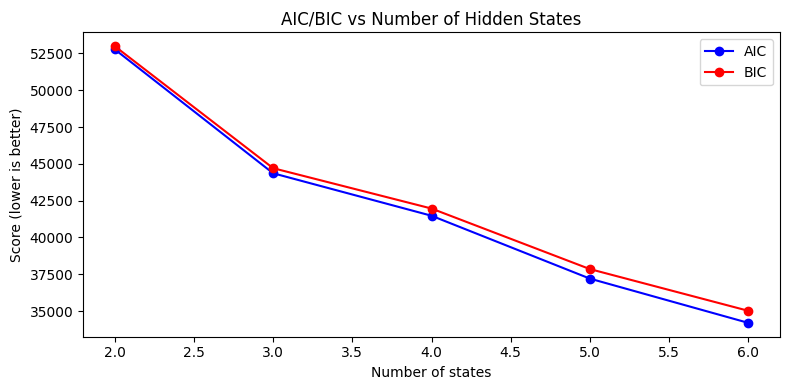

In [34]:
ns   = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 State Persistence — Regime Stability

Average consecutive days per regime before switching. IHSG typically shows longer Bear persistence than SPY, consistent with emerging markets experiencing more sustained downturns.

In [35]:
# State persistence — average days spent in each regime before switching
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}
    
    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1
    
    # Don't forget the last run
    persistence[state_labels[current_state]].append(count)
    
    print("State Persistence (avg consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

compute_persistence(states, state_labels)

State Persistence (avg consecutive days per regime):
Bear         | Avg: 84.2 days | Max: 471 days | Transitions: 22
Neutral      | Avg: 41.6 days | Max: 218 days | Transitions: 71
Bull         | Avg: 49.7 days | Max: 285 days | Transitions: 50


### 9.4 Log-Likelihood — Generalization to Test Set

Per-sample log-likelihood comparison between training and test sets. Note: the generalization gap for IHSG is expected to be larger than for SPY due to structural differences between the training and test periods.

In [36]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if abs(train_score - test_score) < 0.5:
    print("\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting — test score is significantly lower than train")

Train log-likelihood (per sample): -3.2267
Test log-likelihood (per sample): -2.2710
Difference: 0.9557


### 9.5 Transition Matrix

Regime-to-regime transition probabilities. High diagonal values indicate regime persistence. Financially sensible off-diagonal transitions (Bear → Neutral before Bull, not Bear → Bull directly) validate the model has learned realistic market dynamics.

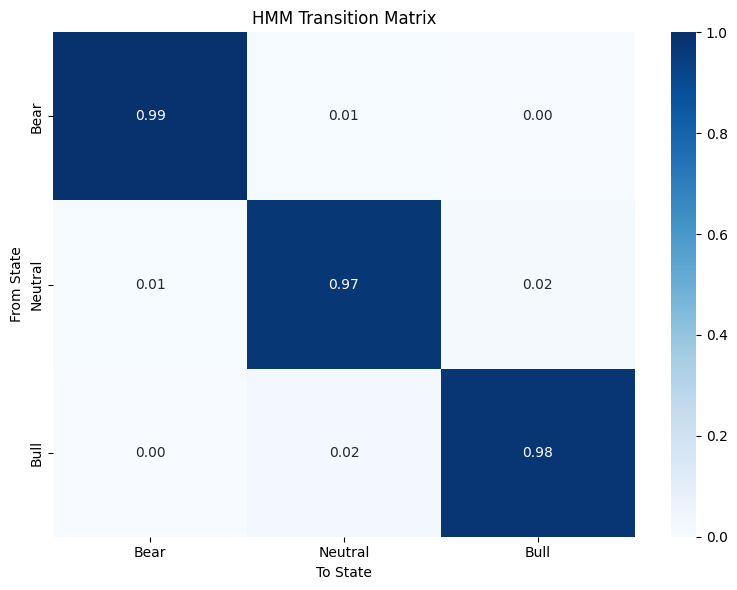

In [37]:
import seaborn as sns

# Get transition matrix and reorder by our state labels
# Build ordered label list from sorted_states
ordered_labels = [state_labels[sorted_states[i]] for i in range(3)]

# Reorder transition matrix rows/cols to match our labeling
transmat = model.transmat_

# Map sorted state indices to transition matrix
idx = [sorted_states[i] for i in range(3)]
reordered = transmat[np.ix_(idx, idx)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(reordered, 
            annot=True, 
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title('HMM Transition Matrix')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

## 10. Regime Prediction

Estimates the most likely regime *k* trading days ahead. This is a **nowcast projected forward**, not a true forecast of regime *changes* — see the note below.

1. **Filter the recent data** with the forward algorithm to get today's regime probabilities, using *only past and present* observations (`forward_filter`). This is deliberately not `predict_proba`, which uses the forward–*backward* algorithm and would let future data leak into the estimate.
2. **Project forward** by multiplying today's distribution by the transition matrix raised to the *k*th power (`transmat_^k`) — i.e. "where does the chain drift in *k* steps if no new information arrives."
3. **Read off** the highest-probability state as the predicted regime.

> **What this can and can't do:** Because the transition matrix is strongly diagonal (regimes persist), the projection mostly says "probably the same regime as today, with rising uncertainty as *k* grows." It is honest about the *current* regime but cannot anticipate a regime *shift* — predicting transitions is a harder problem the transition matrix alone doesn't solve.

In [38]:
# ============================================================
# Regime nowcast using the FORWARD FILTER (no lookahead by construction)
# ============================================================
# Unlike model.predict_proba() (which runs forward-BACKWARD and uses FUTURE
# data to estimate each day), this computes the FILTERED posterior:
#   P(state_t | observations 1..t)  -- past and present only.
# At the final day the two happen to agree, but this version is honest at
# EVERY timestep, so it can't accidentally leak the future.

def forward_filter(model, scaled):
    """Filtered posteriors P(state_t | obs_1..t) for each t. Past-only, numerically stable."""
    framelogprob = model._compute_log_likelihood(scaled)   # log P(obs_t | state_i)
    n_obs, n_states = framelogprob.shape
    filtered = np.zeros((n_obs, n_states))

    def normalize_log(v):
        m = v.max()
        return v - (m + np.log(np.sum(np.exp(v - m))))     # log of normalized dist

    # t = 0: start distribution × emission
    log_alpha = np.log(model.startprob_ + 1e-300) + framelogprob[0]
    filtered[0] = np.exp(normalize_log(log_alpha))

    # t > 0: predict with transition matrix, then update with the new observation
    for t in range(1, n_obs):
        pred = np.log(filtered[t-1] @ model.transmat_ + 1e-300)
        log_alpha = pred + framelogprob[t]
        filtered[t] = np.exp(normalize_log(log_alpha))

    return filtered


def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    scaled = scaler.transform(recent_data)

    # FILTERED current-state distribution (past-only) -- the honest "today" estimate
    filtered = forward_filter(model, scaled)
    current_probs = filtered[-1]

    # Project k steps ahead under the transition matrix (assumes persistence,
    # no new information arrives)
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(3):
        label = state_labels[sorted_states[i]]
        prob  = future_probs[sorted_states[i]]
        print(f"  {label:12s}: {prob:.4f} ({prob*100:.2f}%)")
    return predicted_label, future_probs


# Use last 60 days as recent data
recent_data = features.iloc[-60:]
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear        : 0.0000 (0.00%)
  Neutral     : 0.0202 (2.02%)
  Bull        : 0.9798 (97.98%)

Prediction 5 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear        : 0.0018 (0.18%)
  Neutral     : 0.0914 (9.14%)
  Bull        : 0.9068 (90.68%)

Prediction 10 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear        : 0.0072 (0.72%)
  Neutral     : 0.1628 (16.28%)
  Bull        : 0.8300 (83.00%)



In [39]:
def walk_forward_hmm(features, n_splits=5, n_components=3):
    total = len(features)
    fold_size = total // (n_splits + 1)
    
    results = []
    for i in range(1, n_splits + 1):
        train = features.iloc[:fold_size * i]
        test = features.iloc[fold_size * i : fold_size * (i + 1)]
        
        scaler = RobustScaler()
        scaled_train = scaler.fit_transform(train)
        scaled_test = scaler.transform(test)
        
        model = GaussianHMM(n_components=n_components, 
                           covariance_type="full", 
                           n_iter=200, 
                           random_state=42)
        model.fit(scaled_train)
        
        train_score = model.score(scaled_train) / len(scaled_train)
        test_score = model.score(scaled_test) / len(scaled_test)
        
        print(f"Fold {i} | Train: {len(train)} days | "
              f"Test: {len(test)} days | "
              f"Train LL: {train_score:.4f} | "
              f"Test LL: {test_score:.4f} | "
              f"Gap: {abs(train_score-test_score):.4f}")
        results.append((train_score, test_score))
    
    avg_gap = np.mean([abs(r[0]-r[1]) for r in results])
    print(f"\nAverage gap across folds: {avg_gap:.4f}")
    return results

results = walk_forward_hmm(features, n_splits=5, n_components=3)

Fold 1 | Train: 1215 days | Test: 1215 days | Train LL: -3.4016 | Test LL: -2.3639 | Gap: 1.0377
Fold 2 | Train: 2430 days | Test: 1215 days | Train LL: -3.0665 | Test LL: -3.2234 | Gap: 0.1569
Fold 3 | Train: 3645 days | Test: 1215 days | Train LL: -2.8269 | Test LL: -1.4494 | Gap: 1.3775
Fold 4 | Train: 4860 days | Test: 1215 days | Train LL: -3.1190 | Test LL: -2.1507 | Gap: 0.9682
Fold 5 | Train: 6075 days | Test: 1215 days | Train LL: -3.2213 | Test LL: -1.6765 | Gap: 1.5448

Average gap across folds: 1.0170


In [40]:
# ============================================================
# WALK-FORWARD VALIDATION WITH PERIODIC RE-FITTING
# ============================================================
# Unlike the train/test split (one cut, one frozen model), this marches
# forward in time: train on everything up to "now", predict the next year,
# then refit with the new year included. Each prediction uses ONLY past data,
# which is how the model would actually run in production.
#
# NOTE: uses its own wf_* variable names so it does NOT overwrite `model`,
# `states`, or `scaler` from the cells above.

min_train_days = 252 * 3 # need at least ~3 years before first prediction
refit_every = 252        # refit nce per trading year
wf_n_states = 3

wf_states = np.full(len(features), -1, dtype=int) # -1 = inside initial trading period
wf_labels = {}                                    # per-fold Bear/Neutral/Bull Mapping

fold = 1
cursor = min_train_days

while cursor < len(features):
    train = features.iloc[:cursor]
    test_end = min(cursor + refit_every, len(features))
    test = features.iloc[cursor:test_end]

    # Scale on train only (no leakage into the held out year)
    wf_scaler = RobustScaler()
    wf_scaled_tr = wf_scaler.fit_transform(train)
    wf_scaled_te = wf_scaler.transform(test)

    # Multi-restart fit; keep best by train log-likelihood
    best_model, best_score = None, -np.inf
    for seed in range(20):
        cand = GaussianHMM(n_components=wf_n_states, covariance_type="full", n_iter=200, random_state=seed)
        try:
            cand.fit(wf_scaled_tr)
            s = cand.score(wf_scaled_tr)
            if s > best_score:
                best_score, best_model = s, cand
        except Exception:
            continue

    # Predict the best held-out year
    fold_test_states = best_model.predict(wf_scaled_te)

    # Label THIS fold's state by mean return (state indices are arbritrary per fit, 
    # so each fold needs its own Bear/Neutral/Bull mapping)
    tr_states = best_model.predict(wf_scaled_tr)
    fold_means = [train['returns'].values[tr_states == s].mean() for s in range(wf_n_states)]
    order = np.argsort(fold_means)
    wf_labels[fold] = {order[0]: 'Bear', order[1]: 'Neutral', order[2]:'Bull'}

    wf_states[cursor:test_end] = fold_test_states

    print(f"Fold {fold:2d} | Train: {len(train):4d} days ({len(train)/252:.1f}) | "
          f"Test: {len(test):3d} days | LL/sample: {best_score/len(train):.4f} | "
          f"Converged: {best_model.monitor_.converged}")
    
    cursor = test_end
    fold += 1

print(f"\nOut-of-sample days predicted: {(wf_states != -1).sum()}")
print(f"Initial trading days (not predicted): {(wf_states == -1).sum()}")

Fold  1 | Train:  756 days (3.0) | Test: 252 days | LL/sample: -1.5683 | Converged: True
Fold  2 | Train: 1008 days (4.0) | Test: 252 days | LL/sample: -2.3935 | Converged: True
Fold  3 | Train: 1260 days (5.0) | Test: 252 days | LL/sample: -2.7287 | Converged: True
Fold  4 | Train: 1512 days (6.0) | Test: 252 days | LL/sample: -2.9434 | Converged: True
Fold  5 | Train: 1764 days (7.0) | Test: 252 days | LL/sample: -2.9953 | Converged: True
Fold  6 | Train: 2016 days (8.0) | Test: 252 days | LL/sample: -2.9028 | Converged: True
Fold  7 | Train: 2268 days (9.0) | Test: 252 days | LL/sample: -2.8475 | Converged: True
Fold  8 | Train: 2520 days (10.0) | Test: 252 days | LL/sample: -2.8979 | Converged: True
Fold  9 | Train: 2772 days (11.0) | Test: 252 days | LL/sample: -2.9095 | Converged: True
Fold 10 | Train: 3024 days (12.0) | Test: 252 days | LL/sample: -2.8573 | Converged: True
Fold 11 | Train: 3276 days (13.0) | Test: 252 days | LL/sample: -2.8771 | Converged: True
Fold 12 | Train: 

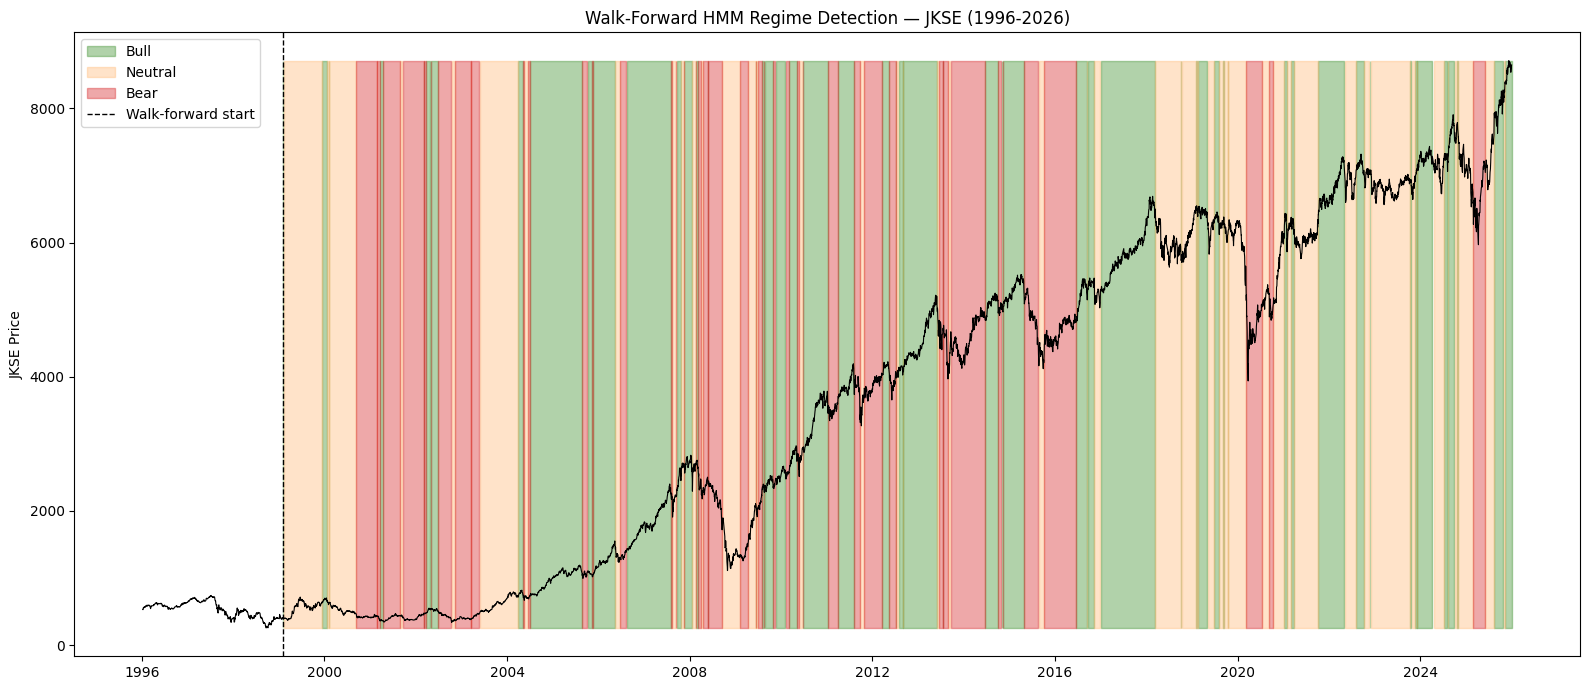

In [41]:
# Walk-forward regime chart - each fold relabeled with its own mapping
fig, ax = plt.subplots(figsize=(16, 7))

close_wf = data['Close'].squeeze().loc[features.index]
ax.plot(features.index, close_wf, color='black', linewidth=0.8, zorder=3)

wf_colors = {'Bear': '#d62728', 'Neutral': '#ffbb78', 'Bull': '#3c902b'}

# Translate per-fold state indices into Bear/Neutral/Bull strings day by day
wf_regime_labels = np.full(len(features), '', dtype=object)
cursor = min_train_days
for fold_num in range(1, len(wf_labels) + 1):
    test_end = min(cursor + refit_every, len(features))
    mapping  = wf_labels[fold_num]
    for day in range(cursor, test_end):
        wf_regime_labels[day] = mapping.get(wf_states[day], 'Unknown')
    cursor = test_end

for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ax.fill_between(features.index, close_wf.min(), close_wf.max(),
                    where=mask, alpha=0.4, color=wf_colors[regime],
                    label=regime, zorder=1)

ax.axvline(features.index[min_train_days], color='black', linestyle='--',
           linewidth=1, label='Walk-forward start')
ax.legend()
ax.set_title('Walk-Forward HMM Regime Detection — JKSE (1996-2026)')
ax.set_ylabel('JKSE Price')
plt.tight_layout()
plt.show()

In [42]:
# Out-of-sample regime statistics (walk-forward predictions only)
print("Walk-Forward Regime Statistics (out-of-sample):")
for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ret = features['returns'].values[mask]
    if len(ret) > 0:
        print(f"{regime:8s} | Mean return: {ret.mean():+.5f} | "
              f"Std: {ret.std():.5f} | Days: {mask.sum()}")

Walk-Forward Regime Statistics (out-of-sample):
Bull     | Mean return: +0.00121 | Std: 0.00886 | Days: 2607
Neutral  | Mean return: +0.00021 | Std: 0.01592 | Days: 2185
Bear     | Mean return: -0.00032 | Std: 0.01431 | Days: 1746


## 13. Limitations & Future Work

### Known Limitations

- **Gaussian emission assumption** — verified empirically for this dataset via histogram inspection, but real return distributions have fat tails that a Gaussian may underestimate in extreme scenarios. GMMHMM is a natural upgrade path

- **Primarily a volatility regime detector** — the Bear state is most reliably triggered by elevated daily volatility, which coincides with sudden crashes. Slow grinding bear markets driven by gradual sentiment deterioration (e.g. prolonged commodity downturns) are harder to detect cleanly using price and volume features alone

- **Slow grinding bear markets** — the model struggles to detect bear markets without extreme daily volatility spikes. Addressing this would require additional macroeconomic features (BI rate, commodity prices, USD/IDR) beyond price data

- **Static model** — trained once on historical data; in production the model would need periodic retraining as market conditions evolve. The walk-forward validation results show the generalization gap varies significantly across time periods, suggesting sensitivity to structural breaks

- **Data quality** — Yahoo Finance IHSG data has known gaps and inconsistencies, particularly for volume. This is why volume was excluded as a feature. Production use would require a more reliable data source such as IDX direct feeds or a commercial provider

- **Larger generalization gap than SPY** — the train/test log-likelihood difference is larger than the SPY model, partly because the post-2021 Indonesian market entered a structurally different phase (post-COVID recovery, commodity supercycle) not well represented in the training period

- **Currency effects** — IHSG is priced in IDR; significant currency moves (taper tantrum 2013, COVID 2020) affect returns in ways not captured by price-only features

- **Commodity sensitivity** — IHSG is heavily influenced by commodity cycles (palm oil, coal, nickel) which are not captured by price features alone. A commodity price feature could meaningfully improve Bear detection for IHSG specifically

- **3 states vs 4** — the simpler 3-state model (Bear, Neutral, Bull) was chosen over 4 states because IHSG data did not support a meaningful Strong Bull / Weak Bull distinction. This means the model cannot differentiate between strong and mild bull conditions, unlike the SPY model

- **Initialization sensitivity** — like the SPY model, IHSG results are sensitive to random initialization. A production system should conduct a seed search rather than relying on a fixed random state

### Features Tested but Not Included

| Feature | Result |
|---|---|
| Volume trend | Unreliable Yahoo Finance data for IHSG — frequent gaps |
| Long momentum (30d) | Significantly increased generalization gap |
| Overnight gap | Minimal improvement, added noise for index-level data |

### Future Work
- Source higher quality IHSG data directly from IDX or a commercial provider
- Add commodity price features (palm oil, coal, nickel) relevant to Indonesian market
- Add USD/IDR exchange rate as a macroeconomic feature
- Implement rolling retraining window for production deployment
- Extend to individual Indonesian stocks (BBCA, BBRI, TLKM etc.)
- Explore macroeconomic features (BI rate, inflation) for improved slow bear market detection
- Investigate overnight gap feature more thoroughly for individual Indonesian stocks where US overnight moves may be more impactful than at index level